In [ ]:
import pandas as pd
import numpy as np

csv_path = "DeepLearning-SingleLayerPerceptron-Farhan536804.xlsx - Data.csv"

# The CSV has no header row, so the column names are assigned manually based on the template provided in the assignment. The last column is the class label (Species).
data = pd.read_csv(
    csv_path,
    header=None,
    names=["X1", "X2", "X3", "X4", "Species"]
)

# Encode the class labels:
# Iris-setosa = 0
# Iris-versicolor = 1
data["Target"] = data["Species"].map({
    "Iris-setosa": 0,
    "Iris-versicolor": 1
})

# Check the imported dataset
print("FULL DATASET")
print(data)
print("\nDataset shape:", data.shape)
print("\nClass counts:")
print(data["Species"].value_counts())

# Split the dataset into training and validation sets. The first 40 samples of each class are used for training, and the last 10 samples of each class are used for validation.

setosa = data[data["Species"] == "Iris-setosa"].reset_index(drop=True)
versicolor = data[data["Species"] == "Iris-versicolor"].reset_index(drop=True)

# Training: first 40 samples from each class = 80 rows
data_train = pd.concat([
    setosa.iloc[:40],
    versicolor.iloc[:40]
], ignore_index=True)

# Validation: last 10 samples from each class = 20 rows
data_validation = pd.concat([
    setosa.iloc[40:50],
    versicolor.iloc[40:50]
], ignore_index=True)

# Keep only the columns used by the SLP
data_train = data_train[["X1", "X2", "X3", "X4", "Target"]]
data_validation = data_validation[["X1", "X2", "X3", "X4", "Target"]]

print("\nTRAINING DATA")
print(data_train)
print("\nTraining shape:", data_train.shape)
print("Training target counts:")
print(data_train["Target"].value_counts().sort_index())

print("\nVALIDATION DATA")
print(data_validation)
print("\nValidation shape:", data_validation.shape)
print("Validation target counts:")
print(data_validation["Target"].value_counts().sort_index())


FULL DATASET
     X1   X2   X3   X4          Species  Target
0   5.1  3.5  1.4  0.2      Iris-setosa       0
1   4.9  3.0  1.4  0.2      Iris-setosa       0
2   4.7  3.2  1.3  0.2      Iris-setosa       0
3   4.6  3.1  1.5  0.2      Iris-setosa       0
4   5.0  3.6  1.4  0.2      Iris-setosa       0
..  ...  ...  ...  ...              ...     ...
95  5.7  3.0  4.2  1.2  Iris-versicolor       1
96  5.7  2.9  4.2  1.3  Iris-versicolor       1
97  6.2  2.9  4.3  1.3  Iris-versicolor       1
98  5.1  2.5  3.0  1.1  Iris-versicolor       1
99  5.7  2.8  4.1  1.3  Iris-versicolor       1

[100 rows x 6 columns]

Dataset shape: (100, 6)

Class counts:
Species
Iris-setosa        50
Iris-versicolor    50
Name: count, dtype: int64

TRAINING DATA
     X1   X2   X3   X4  Target
0   5.1  3.5  1.4  0.2       0
1   4.9  3.0  1.4  0.2       0
2   4.7  3.2  1.3  0.2       0
3   4.6  3.1  1.5  0.2       0
4   5.0  3.6  1.4  0.2       0
..  ...  ...  ...  ...     ...
75  6.0  3.4  4.5  1.6       1
76  6.

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def predict_class(probability):
    return 1 if probability >= 0.5 else 0

In [3]:
learning_rate = 0.1
num_epochs = 5

# Initial bias
bias = 0.5

# Initial theta1, theta2, theta3, theta4
theta = np.array([
    0.5,
    0.5,
    0.5,
    0.5
], dtype=float)


# Store summaries
training_history = []
validation_history = []

# Save every training calculation
training_details = []

# Save every validation calculation
validation_details = []

In [4]:
# PREPARE TRAINING DATA

X_train = data_train[
    ["X1", "X2", "X3", "X4"]
].to_numpy(dtype=float)

y_train = data_train["Target"].to_numpy(dtype=int)

# PREPARE VALIDATION DATA

X_val = data_validation[
    ["X1", "X2", "X3", "X4"]
].to_numpy(dtype=float)

y_val = data_validation["Target"].to_numpy(dtype=int)


print("Training:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nValidation:")
print("X_val:", X_val.shape)
print("y_val:", y_val.shape)

Training:
X_train: (80, 4)
y_train: (80,)

Validation:
X_val: (20, 4)
y_val: (20,)


In [ ]:
for epoch in range(1, num_epochs + 1):

    # TRAINING

    epoch_train_losses = []
    epoch_train_correct = 0

    for i in range(len(X_train)):

        x = X_train[i]
        target = y_train[i]

        # Forward propagation

        z = bias + np.dot(theta, x)

        gz = sigmoid(z)

        prediction = predict_class(gz)

        error = gz - target

        sse = error ** 2


        # Accuracy
        if prediction == target:
            epoch_train_correct += 1


        # Save current calculation
        training_details.append({
            "Epoch": epoch,
            "No": i + 1,
            "X1": x[0],
            "X2": x[1],
            "X3": x[2],
            "X4": x[3],
            "Target": target,

            "Bias": bias,
            "Theta1": theta[0],
            "Theta2": theta[1],
            "Theta3": theta[2],
            "Theta4": theta[3],

            "z": z,
            "g(z)": gz,
            "Prediction": prediction,
            "Error": error,
            "SSE": sse
        })


        epoch_train_losses.append(sse)

        # BACKPROP / GRADIENT

        # derivative of SSE with respect to z
        d_common = (
            2
            * error
            * gz
            * (1 - gz)
        )

        dbias = d_common

        dtheta = d_common * x


        # UPDATE WEIGHTS

        bias = bias - learning_rate * dbias

        theta = theta - learning_rate * dtheta

    # TRAINING SUMMARY

    train_loss = np.mean(epoch_train_losses)

    train_accuracy = (
        epoch_train_correct
        / len(X_train)
    ) * 100


    training_history.append({
        "Epoch": epoch,
        "Average Loss": train_loss,
        "Accuracy (%)": train_accuracy
    })


    # VALIDATION
    # We use the final weights obtained from the current epoch.

    epoch_val_losses = []
    epoch_val_correct = 0

    for i in range(len(X_val)):

        x = X_val[i]
        target = y_val[i]


        # Forward propagation only

        z = bias + np.dot(theta, x)

        gz = sigmoid(z)

        prediction = predict_class(gz)

        error = gz - target

        sse = error ** 2


        if prediction == target:
            epoch_val_correct += 1


        epoch_val_losses.append(sse)


        validation_details.append({
            "Epoch": epoch,
            "No": i + 1,
            "X1": x[0],
            "X2": x[1],
            "X3": x[2],
            "X4": x[3],
            "Target": target,

            "Bias": bias,
            "Theta1": theta[0],
            "Theta2": theta[1],
            "Theta3": theta[2],
            "Theta4": theta[3],

            "z": z,
            "g(z)": gz,
            "Prediction": prediction,
            "Error": error,
            "SSE": sse
        })


    # VALIDATION SUMMARY

    val_loss = np.mean(epoch_val_losses)

    val_accuracy = (
        epoch_val_correct
        / len(X_val)
    ) * 100


    validation_history.append({
        "Epoch": epoch,
        "Validation Loss": val_loss,
        "Validation Accuracy (%)": val_accuracy
    })

In [6]:
training_summary = pd.DataFrame(training_history)

validation_summary = pd.DataFrame(validation_history)


print("TRAINING SUMMARY")
print(training_summary.to_string(index=False))


print("\nVALIDATION SUMMARY")
print(validation_summary.to_string(index=False))

TRAINING SUMMARY
 Epoch  Average Loss  Accuracy (%)
     1      0.449889         52.50
     2      0.037452         95.00
     3      0.024372         97.50
     4      0.017357         97.50
     5      0.012740         98.75

VALIDATION SUMMARY
 Epoch  Validation Loss  Validation Accuracy (%)
     1         0.328951                     50.0
     2         0.247289                     50.0
     3         0.175892                     50.0
     4         0.119381                     85.0
     5         0.081581                    100.0


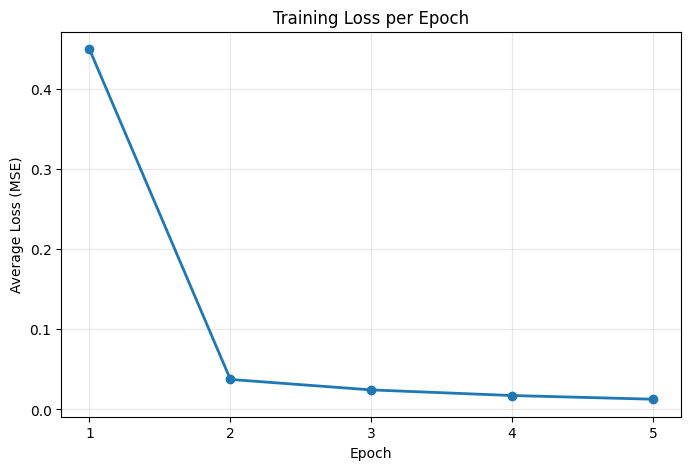

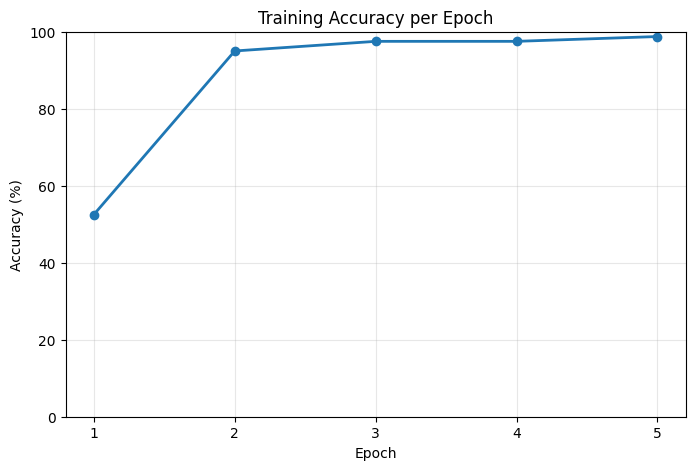

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(
    training_summary["Epoch"],
    training_summary["Average Loss"],
    marker="o",
    linewidth=2
)

plt.title("Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Average Loss (MSE)")
plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    training_summary["Epoch"],
    training_summary["Accuracy (%)"],
    marker="o",
    linewidth=2
)

plt.title("Training Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.xticks(range(1, 6))
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

plt.show()

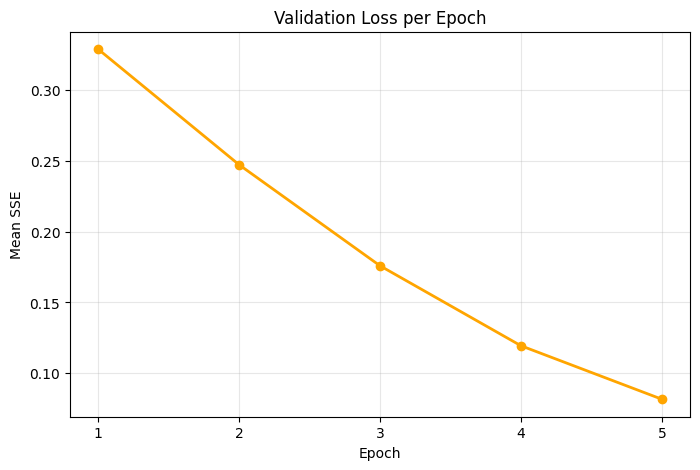

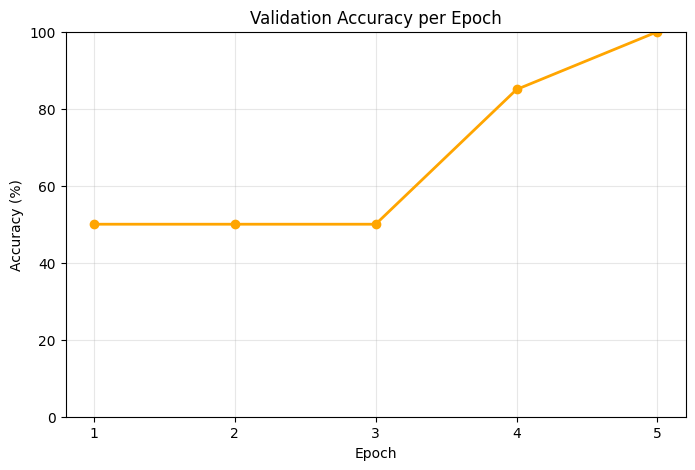

In [9]:
plt.figure(figsize=(8, 5))

plt.plot(
    validation_summary["Epoch"],
    validation_summary["Validation Loss"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.title("Validation Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Mean SSE")

plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)

plt.show()

plt.figure(figsize=(8, 5))

plt.plot(
    validation_summary["Epoch"],
    validation_summary["Validation Accuracy (%)"],
    marker="o",
    linewidth=2,
    color="orange"
)

plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.xticks(range(1, 6))
plt.ylim(0, 100)
plt.grid(True, alpha=0.3)

plt.show()

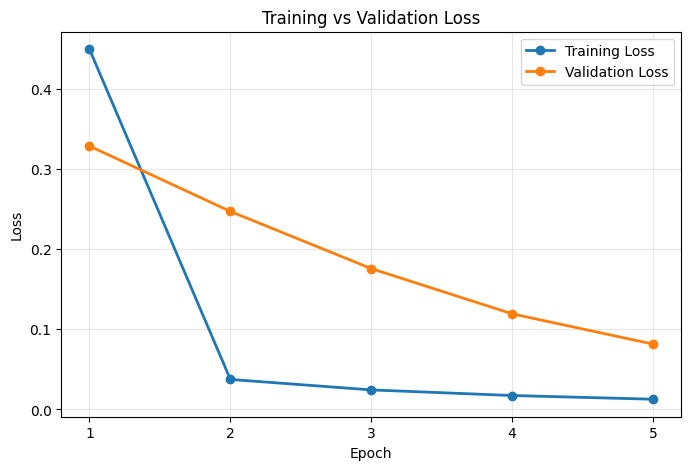

In [10]:
summary = pd.merge(training_summary, validation_summary, on="Epoch")

plt.figure(figsize=(8, 5))

plt.plot(
    summary["Epoch"],
    summary["Average Loss"],
    marker="o",
    linewidth=2,
    label="Training Loss"
)

plt.plot(
    summary["Epoch"],
    summary["Validation Loss"],
    marker="o",
    linewidth=2,
    label="Validation Loss"
)

plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.xticks(range(1, 6))
plt.grid(True, alpha=0.3)
plt.legend()

plt.show()

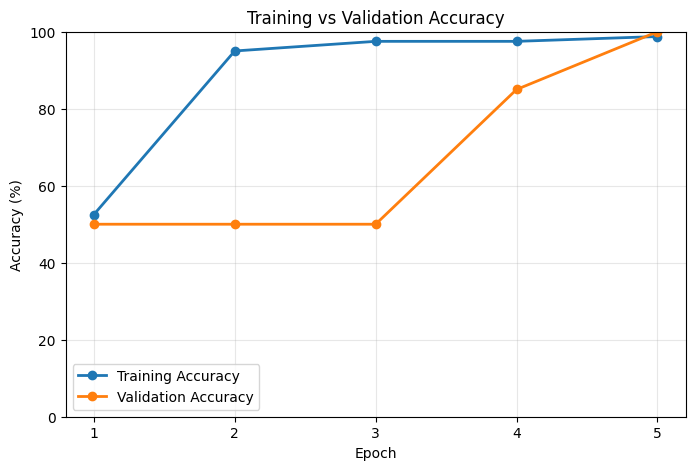

In [11]:
plt.figure(figsize=(8, 5))

plt.plot(
    summary["Epoch"],
    summary["Accuracy (%)"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    summary["Epoch"],
    summary["Validation Accuracy (%)"],
    marker="o",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")

plt.xticks(range(1, 6))
plt.ylim(0, 100)

plt.grid(True, alpha=0.3)
plt.legend()

plt.show()